<a href="https://colab.research.google.com/github/07ashu97912-hub/ML-projects/blob/main/linear_regression/salary_prediction/01_salary_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ml data/Salary_dataset.csv',usecols=['YearsExperience','Salary'])
df.sample(5)

,YearsExperience,Salary
12,4.1,56958.0
14,4.6,61112.0
2,1.6,37732.0
15,5.0,67939.0
21,7.2,98274.0


In [ ]:
df.shape

(30, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


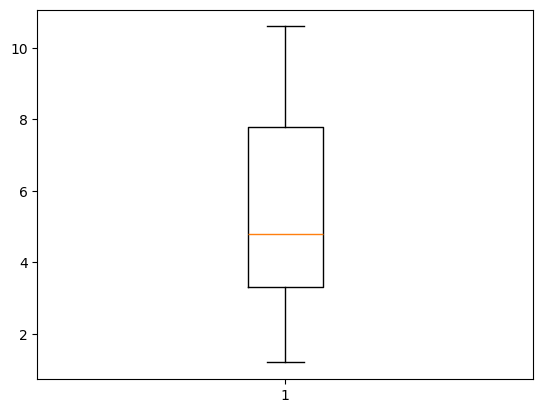

In [ ]:
plt.boxplot(df['YearsExperience'])
plt.show()

<Axes: xlabel='YearsExperience', ylabel='Salary'>

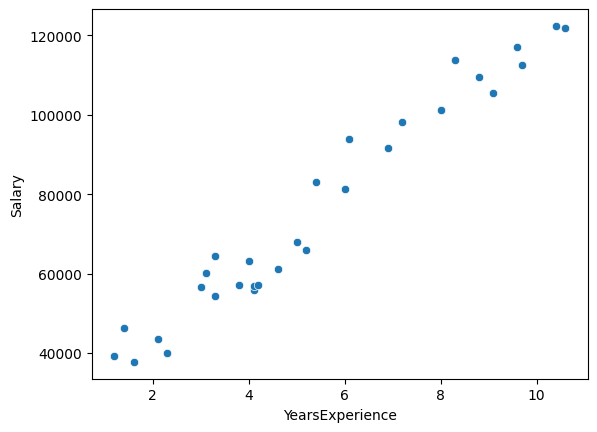

In [ ]:
sns.scatterplot(data=df , x='YearsExperience' , y = 'Salary')

# train test split

In [ ]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(df['YearsExperience'].values.reshape(-1,1), df['Salary'].values.reshape(-1,1), test_size=0.2, random_state=31)

# standard scalar

In [ ]:
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()

xtrain = ss.fit_transform(xtrain)
xtest = ss.transform(xtest)

# linear model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(xtrain,ytrain)
prediction = lr.predict(xtest)

In [ ]:
lr.coef_[0] , lr.intercept_

(array([28030.88806096]), array([78260.875]))

# testing

In [ ]:
from sklearn.metrics import r2_score , mean_squared_error

In [ ]:
r2_score(ytest,prediction)

0.8967649524853984

In [ ]:
mean_squared_error(ytest,prediction)

26623186.97958693

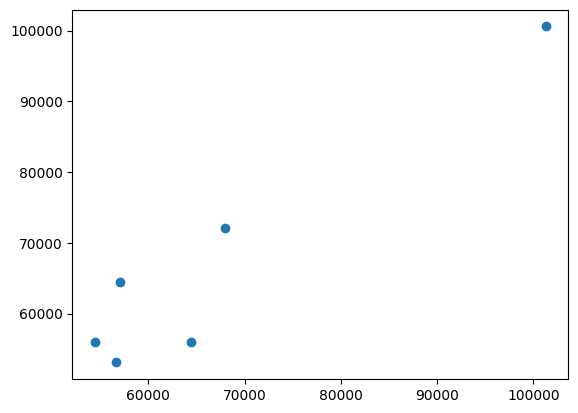

In [ ]:
plt.scatter(ytest , prediction)

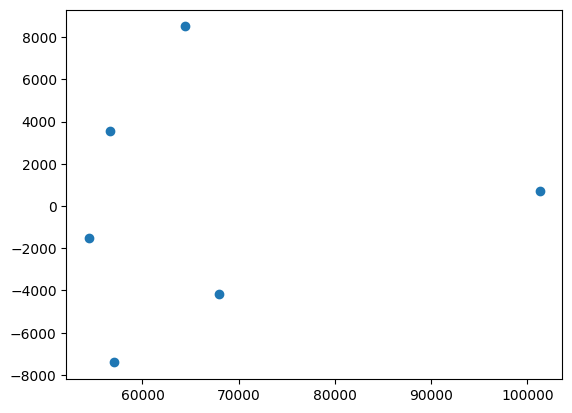

In [ ]:
plt.scatter(ytest, ytest-prediction)

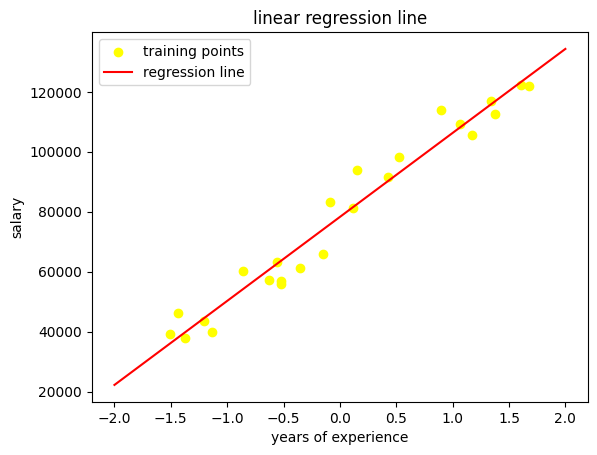

In [ ]:
x = np.linspace(-2,2)
y = 28030.888060962625 * x + 78260.87500000001

plt.scatter(xtrain , ytrain , color='yellow' , label='training points')
plt.plot(x , y , color='red' , label='regression line')

plt.title('linear regression line')
plt.xlabel('years of experience')
plt.ylabel('salary')
plt.legend()
plt.show()

# model deployement

In [ ]:
import joblib

# This saves your trained 'lr' model into a file
joblib.dump(lr, "salary_model.pkl")
print("1. salary_model.pkl has been created successfully!")

1. salary_model.pkl has been created successfully!


In [ ]:
import joblib

# This saves your scaler object 'ss' into a file named scaler.pkl
joblib.dump(ss, "scaler.pkl")
print("scaler.pkl has been created successfully!")

scaler.pkl has been created successfully!


In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn
joblib
numpy


Overwriting requirements.txt


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Title of the web app
st.title("Salary Prediction App 💰")
st.write("Welcome! This app predicts salary based on your experience.")

# 1. Model Selection Dropdown (Ready for your future models!)
selected_model = st.selectbox(
    "Choose a Machine Learning Model",
    ["Linear Regression (Current)", "Advanced Model (Coming Soon)"]
)

# 2. User Input Elements
experience = st.number_input("Years of Experience", min_value=0.0, max_value=50.0, value=1.0, step=0.5)

# 3. Prediction Logic
if st.button("Predict Salary"):
    if selected_model == "Linear Regression (Current)":
        try:
            # Load your saved model file
            lr = joblib.load("salary_model.pkl")
            ss = joblib.load("scaler.pkl")
            # Format input for scikit-learn (needs to be a 2D array)
            input_data = np.array([[experience]])
            scaled_input = ss.transform(input_data)
            prediction = float(lr.predict(scaled_input)[0])
            st.success(f"Estimated Salary: ${prediction:,.2f}")

            # Display result
            st.success(f"Estimated Salary: ${prediction:,.2f}")
        except FileNotFoundError:
            st.error("Error: 'salary_model.pkl' not found. Please ensure the model file is uploaded.")

    elif selected_model == "Advanced Model (Coming Soon)":
        st.info("This model is currently under development. Stay tuned!")


Overwriting app.py


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
from google.colab import output
# This creates a direct clickable link instead of embedding it
print("Click the link below to open your app in a new tab:")
print(output.eval_js("google.colab.kernel.proxyPort(8501)"))

Click the link below to open your app in a new tab:
https://8501-m-s-kkb-usc1c0-3v6mgv1ue5lxr-c.us-central1-0.prod.colab.dev
